In [6]:
import pandas as pd
import numpy as np
df = pd.read_csv("heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [7]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [8]:
## label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["ChestPainType"] = le.fit_transform(df["ChestPainType"])
df["RestingECG"] = le.fit_transform(df["RestingECG"])
df["ExerciseAngina"] = le.fit_transform(df["ExerciseAngina"])
df["ST_Slope"] = le.fit_transform(df["ST_Slope"])
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,3,110,264,0,1,132,0,1.2,1,1
914,68,1,0,144,193,1,1,141,0,3.4,1,1
915,57,1,0,130,131,0,1,115,1,1.2,1,1
916,57,0,1,130,236,0,0,174,0,0.0,1,1


In [9]:
df = df.drop_duplicates()
df = df.dropna()
df = df.drop('HeartDisease', axis='columns')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,1,1,140,289,0,1,172,0,0.0,2
1,49,0,2,160,180,0,1,156,0,1.0,1
2,37,1,1,130,283,0,2,98,0,0.0,2
3,48,0,0,138,214,0,1,108,1,1.5,1
4,54,1,2,150,195,0,1,122,0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,3,110,264,0,1,132,0,1.2,1
914,68,1,0,144,193,1,1,141,0,3.4,1
915,57,1,0,130,131,0,1,115,1,1.2,1
916,57,0,1,130,236,0,0,174,0,0.0,1


In [10]:
from sklearn.preprocessing import StandardScaler
X = df
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [13]:
## K-means
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
Km = KMeans(n_clusters=3, random_state=42)
y_predict = Km.fit_predict(X_pca)
y_predict

array([2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 0, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2,
       1, 1, 2, 2, 2, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2,
       2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1,
       2, 1, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 1, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 2, 2, 2, 1, 2, 1, 0, 2, 0, 2, 0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 2, 1,
       1, 2, 1, 2, 1, 1, 0, 1, 2, 1, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 0,
       1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 0, 0,

In [15]:
df['cluster'] = y_predict
df.head

<bound method NDFrame.head of      Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0     40    1              1        140          289          0           1   
1     49    0              2        160          180          0           1   
2     37    1              1        130          283          0           2   
3     48    0              0        138          214          0           1   
4     54    1              2        150          195          0           1   
..   ...  ...            ...        ...          ...        ...         ...   
913   45    1              3        110          264          0           1   
914   68    1              0        144          193          1           1   
915   57    1              0        130          131          0           1   
916   57    0              1        130          236          0           0   
917   38    1              2        138          175          0           1   

     MaxHR  ExerciseAngina  Oldpeak  ST_Slope  cluster  
0      172               0      0.0         2        2  
1      156               0      1.0         1        2  
2       98               0      0.0         2        2  
3      108               1      1.5         1        1  
4      122               0      0.0         2        2  
..     ...             ...      ...       ...      ...  
913    132               0      1.2         1        2  
914    141               0      3.4         1        1  
915    115               1      1.2         1        1  
916    174               0      0.0         1        2  
917    173               0      0.0         2        2  

[918 rows x 12 columns]>

In [16]:
Km.cluster_centers_

array([[-1.1867821 , -1.55628368],
       [-1.38502948,  0.9228739 ],
       [ 1.52938854,  0.06291524]])

In [18]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = y_predict

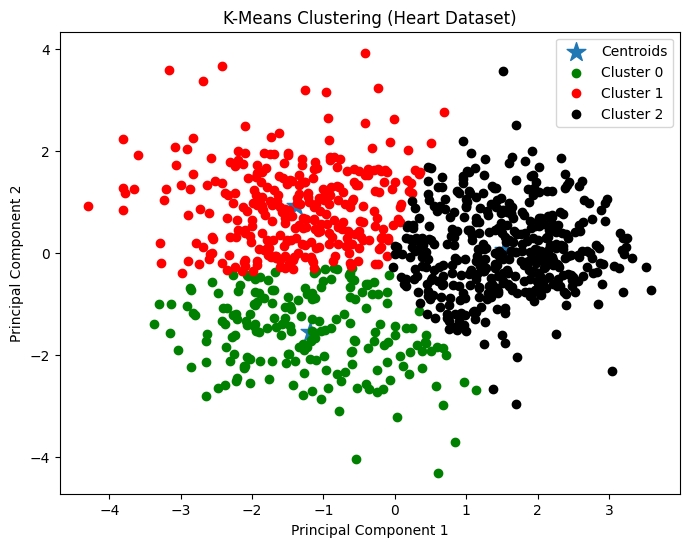

In [19]:
df1 = df_pca[df_pca.cluster == 0]
df2 = df_pca[df_pca.cluster == 1]
df3 = df_pca[df_pca.cluster == 2]
plt.figure(figsize=(8,6))
centroids_pca = Km.cluster_centers_
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],marker='*', s=200, label='Centroids')
plt.scatter(df1.PC1, df1.PC2, color='green', label='Cluster 0')
plt.scatter(df2.PC1, df2.PC2, color='red', label='Cluster 1')
plt.scatter(df3.PC1, df3.PC2, color='black', label='Cluster 2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.title('K-Means Clustering (Heart Dataset)')
plt.show()

In [20]:
import pickle
pickle.dump(Km, open("KMean(2).pkl", "wb"))

In [21]:
import joblib
joblib.dump(Km, "KMean(2).pkl")
joblib.dump(X.columns.tolist(), "model_column24s(1).pkl")

['model_column24s(1).pkl']